# Univariate Zeitreihenanalyse — Gold (XAU/USD)

Dieses Notebook analysiert den Goldpreis (Ticker: `GC=F` von Yahoo Finance) im Zeitraum **2015 bis 2025**.

Wir folgen der klassischen **Box-Jenkins-Methodik**, die aus sieben Schritten besteht:

1. **Visuelle Inspektion** — Wie sieht die Zeitreihe aus? Gibt es einen Trend, Saisonalität, Ausreißer?
2. **Stationaritätstest (ADF-Test)** — Ist die Reihe stationär? Das ist eine Grundvoraussetzung für ARIMA.
3. **Differenzierung** — Falls nicht stationär: Reihe differenzieren, bis sie es ist.
4. **ACF & PACF** — Autokorrelation und partielle Autokorrelation analysieren, um die Modellordnung zu bestimmen.
5. **Modellauswahl (p, d, q)** — ARIMA-Parameter auf Basis der vorherigen Schritte wählen.
6. **Residualdiagnostik** — Sind die Residuen des Modells weißes Rauschen?
7. **Prognose** — Zukünftige Werte vorhersagen und Unsicherheitsintervalle berechnen.

Dieses Notebook deckt **alle sieben Schritte** für die Goldzeitreihe ab.

---
## Schritt 1: Visuelle Inspektion

Bevor wir irgendein statistisches Modell aufstellen, schauen wir uns die Zeitreihe zuerst mit eigenen Augen an. Das gibt uns ein erstes Gefühl dafür:

- Gibt es einen **langfristigen Trend** (steigt oder fällt der Preis über die Jahre)?
- Gibt es Phasen mit höherer oder niedrigerer **Volatilität** (breite vs. enge Schwankungen)?
- Gibt es **strukturelle Brüche** — also Zeitpunkte, an denen sich das Verhalten der Reihe plötzlich verändert hat (z.B. durch eine Krise, einen Krieg, eine Zentralbankentscheidung)?

Die visuelle Analyse ist kein optionaler Schritt — sie ist ein zentraler Teil der Box-Jenkins-Methodik.

In [1]:
import sys
import os

# Add project root to path so we can import from src/
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.utils.data_loader import load_series

In [2]:
# Load the Gold futures series (GC=F)
gold = load_series("GC=F")

[data_loader] Loading cached file: GC_F_2015-01-01_to_2025-05-04.csv


In [3]:
# Basic data overview: types, head, and summary statistics
print("=== Datentypen & Struktur ===")
gold.info()

print("\n=== Erste Zeilen ===")
display(gold.head())

print("\n=== Statistische Kennzahlen ===")
display(gold.describe())

=== Datentypen & Struktur ===
<class 'pandas.DataFrame'>
DatetimeIndex: 2597 entries, 2015-01-02 to 2025-05-02
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2597 non-null   float64
 1   High    2597 non-null   float64
 2   Low     2597 non-null   float64
 3   Open    2597 non-null   float64
 4   Volume  2597 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 121.7 KB

=== Erste Zeilen ===


,Close,High,Low,Open,Volume
Price,,,,,
2015-01-02,1186.000000,1194.500000,1169.500000,1184.000000,138
2015-01-05,1203.900024,1206.900024,1180.099976,1180.300049,470
2015-01-06,1219.300049,1220.000000,1203.500000,1203.500000,97
2015-01-07,1210.599976,1219.199951,1210.599976,1219.199951,29
2015-01-08,1208.400024,1215.699951,1206.300049,1207.000000,92



=== Statistische Kennzahlen ===


,Close,High,Low,Open,Volume
count,2597.000000,2597.000000,2597.000000,2597.000000,2597.000000
mean,1647.375779,1655.239046,1639.381171,1647.148093,5232.058144
std,456.709889,459.674481,453.397554,456.298615,28831.771889
min,1050.800049,1062.000000,1046.199951,1053.699951,0.000000
25%,1266.099976,1270.800049,1260.300049,1266.400024,49.000000
50%,1600.000000,1621.000000,1579.800049,1594.500000,185.000000
75%,1898.599976,1907.699951,1886.099976,1897.300049,574.000000
max,3406.199951,3485.600098,3361.699951,3422.199951,386334.000000


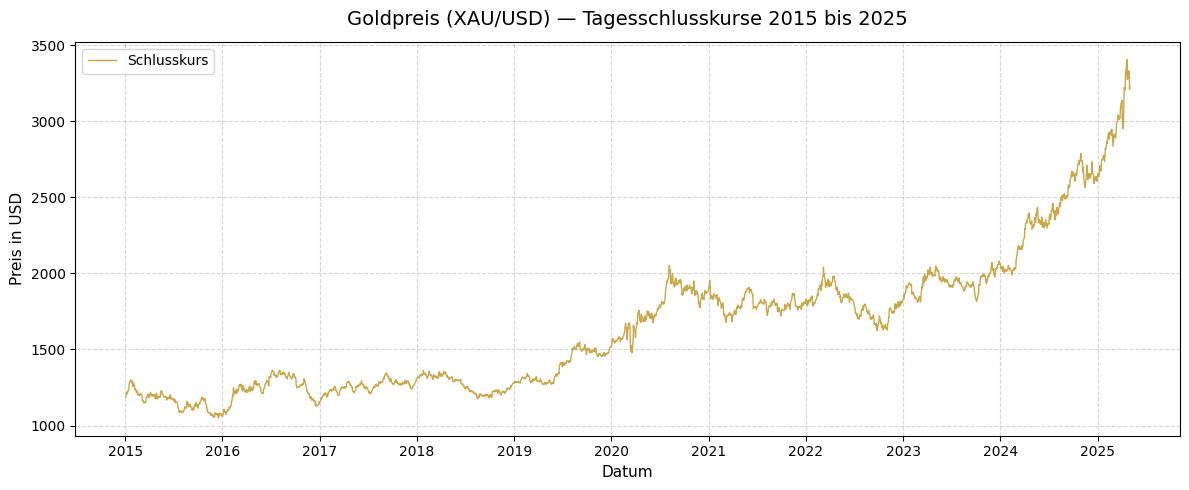

In [4]:
# Plot the daily closing price of Gold over the full sample period
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(gold.index, gold["Close"], color="#C9A84C", linewidth=1.0, label="Schlusskurs")

ax.set_title("Goldpreis (XAU/USD) — Tagesschlusskurse 2015 bis 2025", fontsize=14, pad=12)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Preis in USD", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# Format x-axis with clean year labels
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

---
## Schritt 2: Stationaritätstest (ADF)

Eine Zeitreihe ist **stationär**, wenn Mittelwert, Varianz und Autokorrelationsstruktur sich über die Zeit nicht verändern. ARIMA setzt Stationarität voraus.

Der **Augmented Dickey-Fuller Test** prüft formal, ob eine Reihe einen sogenannten *Unit Root* (Einheitswurzel) hat:

- **H₀:** Die Reihe hat eine Einheitswurzel → **nicht stationär**
- **H₁:** Die Reihe hat keine Einheitswurzel → **stationär**

Faustregel: **p-Wert < 0,05** → H₀ ablehnen → stationär. \
**p-Wert ≥ 0,05** → nicht stationär → wir müssen differenzieren.

**Erwartetes Ergebnis:** Der Goldpreis hat einen klaren langfristigen Aufwärtstrend — wir erwarten daher, dass die Reihe **nicht stationär** ist.

In [5]:
# Import the shared ADF helper — lives in src/utils/preprocessing.py
# so all team members (Gold, BTC, EUR/USD) can reuse it
from src.utils.preprocessing import adf_test

In [6]:
# Run ADF test on the raw Gold closing price series
result_raw = adf_test(gold["Close"], title="Goldpreis (Close) — Rohdaten")


ADF-Test: Goldpreis (Close) — Rohdaten
  Test Statistic: 1.9621521891521625
  p-value: 0.9986217066706323
  Lags Used: 0
  Observations: 2596
  Kritischer Wert (1%):  -3.4329
  Kritischer Wert (5%):  -2.8627
  Kritischer Wert (10%):  -2.5674

  Ergebnis: NICHT STATIONAER ✗  (p = 0.9986)



---
## Schritt 3: Stationarisierung durch Differenzierung

Der ADF-Test hat gezeigt: Der Goldpreis ist **nicht stationär** (p ≈ 1,00). Um ein ARIMA-Modell anwenden zu können, müssen wir die Reihe stationär machen.

### Erste Differenz

Das einfachste Mittel ist die **erste Differenzierung**:

$$y'_t = y_t - y_{t-1}$$

Statt des absoluten Preises betrachten wir die **tägliche Preisveränderung**. Das entfernt den langfristigen Trend, denn wenn sich der Preis gleichmäßig nach oben bewegt, sind die Abstände zwischen aufeinanderfolgenden Tagen annähernd konstant — und eine konstante Reihe um null ist stationär.

Nach der Differenzierung führen wir **zwei Tests** durch:

- **ADF-Test** — H₀: nicht stationär → wir wollen p < 0,05
- **KPSS-Test** — H₀: stationär → wir wollen p > 0,05 (H₀ *nicht* ablehnen)

Wenn **beide Tests übereinstimmen**, können wir sicher sein, dass d = 1 ausreicht. Der ARIMA-Parameter **d** gibt an, wie oft wir differenzieren müssen — wir erwarten d = 1.

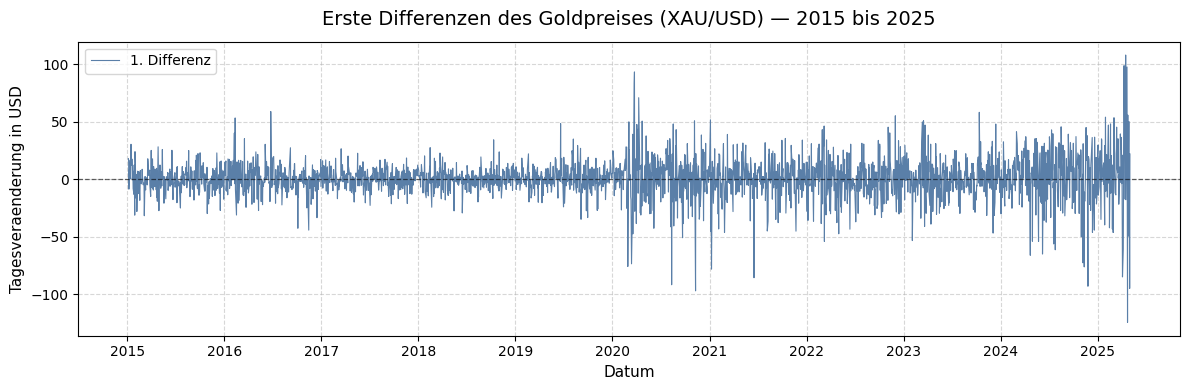

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# First-order differencing: daily price changes
gold_diff = gold["Close"].diff().dropna()

# Plot the differenced series
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(gold_diff.index, gold_diff.values, color="#5A7FA8", linewidth=0.8, label="1. Differenz")
ax.axhline(0, color="black", linewidth=0.9, linestyle="--", alpha=0.6)

ax.set_title("Erste Differenzen des Goldpreises (XAU/USD) — 2015 bis 2025", fontsize=14, pad=12)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Tagesveraenderung in USD", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Beobachtungen zur differenzierten Reihe

_(Hier kommen Luis' Beobachtungen zur differenzierten Reihe rein)_

In [8]:
from src.utils.preprocessing import adf_test, kpss_test

# ADF test on the differenced series — we expect p < 0.05 (stationary)
result_adf_diff = adf_test(gold_diff, title="Gold (1. Differenz)")

# KPSS test on the differenced series — we expect p > 0.05 (fail to reject H0)
result_kpss_diff = kpss_test(gold_diff, title="Gold (1. Differenz)")


ADF-Test: Gold (1. Differenz)
  Test Statistic: -52.03521283532743
  p-value: 0.0
  Lags Used: 0
  Observations: 2595
  Kritischer Wert (1%):  -3.4329
  Kritischer Wert (5%):  -2.8627
  Kritischer Wert (10%):  -2.5674

  Ergebnis: STATIONAER ✓  (p = 0.0000)


KPSS-Test: Gold (1. Differenz)
  Test Statistic: 0.5544259556858718
  p-value: 0.02940856853921805
  Lags Used: 7
  Kritischer Wert (10%):  0.3470
  Kritischer Wert (5%):  0.4630
  Kritischer Wert (2.5%):  0.5740
  Kritischer Wert (1%):  0.7390

  Ergebnis: NICHT STATIONAER ✗  (p = 0.0294)



### Interpretation der Testergebnisse

Die beiden Tests testen gewissermaßen aus **entgegengesetzten Richtungen**:

| Test | H₀ (Nullhypothese) | Stationaritaet bestaetigt, wenn... |
|------|--------------------|------------------------------------|
| **ADF** | Reihe hat Einheitswurzel (nicht stationaer) | p-Wert **< 0,05** (H₀ ablehnen) |
| **KPSS** | Reihe ist stationaer | p-Wert **> 0,05** (H₀ *nicht* ablehnen) |

#### Ergebnisse fuer Gold (1. Differenz)

| Test | Teststatistik | p-Wert | Ergebnis |
|------|---------------|--------|----------|
| ADF  | -52,04 | p ≈ 0,000 | STATIONAER ✓ |
| KPSS | 0,554  | p = 0,029 | NICHT STATIONAER ✗ |

#### Was bedeutet diese Diskrepanz?

Die beiden Tests widersprechen sich leicht — das ist bei Finanz-Zeitreihen nicht ungewoehnlich und hat eine konkrete Ursache:

Der ADF-Test prueft, ob ein **langfristiger Trend (Unit Root)** vorliegt. Das tut er nach der Differenzierung klar nicht mehr (p ≈ 0).

Der KPSS-Test schlaegt dennoch an, weil er auf **zeitlich variierende Varianz** reagiert. Im differenzierten Goldpreis sieht man, dass ruhige Phasen (z.B. 2015-2018) und turbulente Phasen (z.B. 2020, 2024) abwechseln — die Schwankungsbreite ist nicht konstant. Dieses Phaenomen heißt **Heteroskedastizitaet** (ARCH/GARCH-Effekte).

**Fazit fuer unser ARIMA-Modell:** Der KPSS-Wert (0,554) liegt knapp ueber dem 5%-Schwellenwert (0,463) — es ist ein Grenzfall, kein klares Signal. Der ADF-Test mit p ≈ 0 und einer Teststatistik von -52 ist sehr eindeutig. Fuer die Box-Jenkins-Methodik reicht das: **d = 1** ist ausreichend. Die Heteroskedastizitaet koennte spaeter mit einem GARCH-Modell adressiert werden — das ist jedoch ein separater Schritt jenseits von ARIMA.

## Erste Beobachtungen

Gold zeigt insgesamt einen klaren langfristigen Aufwärtstrend. Zwischen 2015 und 2025 steigt der Preis ungefähr von 1.200 USD auf rund 2.800 USD und hat sich damit mehr als verdoppelt. Schon beim ersten Blick auf den Chart erkennt man, dass die Zeitreihe nicht stationär ist.

Von 2015 bis etwa 2018 bewegt sich Gold eher seitwärts. Der Preis schwankt in dieser Phase hauptsächlich zwischen ungefähr 1.050 und 1.350 USD, ohne einen wirklich starken Trend nach oben oder unten.

Der erste große Anstieg kommt dann 2019 bis 2020. Besonders während der COVID-19-Krise steigt Gold stark an und erreicht im August 2020 ein damaliges Allzeithoch von ungefähr 2.050 USD. Das passt gut zur Rolle von Gold als sogenannter „Safe Haven“, also als sicherer Hafen in unsicheren Zeiten.

Danach folgt zwischen 2021 und 2022 wieder ein deutlicher Rückgang. Der Preis fällt teilweise auf etwa 1.600 USD zurück. Ein möglicher Grund dafür sind die steigenden Zinsen in diesem Zeitraum, weil Gold selbst keine laufende Rendite abwirft und dadurch im Vergleich zu verzinsten Anlagen weniger attraktiv wird.

Ab Ende 2022 startet dann die nächste starke Rally. Der Goldpreis steigt fast durchgehend weiter an und erreicht bis Ende 2024 ungefähr 2.800 USD. Gründe dafür könnten geopolitische Unsicherheiten, hohe Goldkäufe durch Zentralbanken und Erwartungen auf zukünftige Zinssenkungen sein.

Auffällig ist außerdem, dass die Volatilität nicht konstant bleibt. Zwischen 2015 und 2018 wirkt der Markt vergleichsweise ruhig, während es besonders 2020 und später nochmal 2024 deutlich stärkere Schwankungen gibt. Das spricht dafür, dass die Zeitreihe heteroskedastische Eigenschaften besitzt.
